# 04 — Modeling

Train and compare Logistic Regression, Random Forest, and XGBoost on the feature matrix.

**Input:** `data/processed/playoff_features.parquet`  
**Output:** Metrics comparison table, ROC curves, calibration plots, best model saved to `models/`

**Train:** seasons 2014-15 through 2021-22  
**Test (holdout):** seasons 2022-23 and 2023-24

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import RocCurveDisplay

sns.set_theme(style="whitegrid")
sys.path.insert(0, str(Path().resolve().parent))
from src.models import (
    FEATURE_COLS,
    TARGET_COL,
    build_logistic_pipeline,
    build_random_forest_pipeline,
    build_xgboost_pipeline,
    compare_models,
    cross_validate_temporal,
    evaluate_model,
    save_model,
    train_test_split_by_season,
)

In [2]:
# CONFIG
PROCESSED_DIR = Path().resolve().parent / "data" / "processed"
FEATURES_PATH = PROCESSED_DIR / "playoff_features.parquet"
TEST_SEASONS = ["2022-23", "2023-24"]

## 1. Load Data + Train/Test Split

In [3]:
df = pd.read_parquet(FEATURES_PATH)
train_df, test_df = train_test_split_by_season(df, TEST_SEASONS)
print(f"Train: {len(train_df)} games | Test (holdout): {len(test_df)} games")

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL]

Train: 582 games | Test (holdout): 166 games


## 2. Naive Baseline

In [4]:
naive_acc = y_test.mean()  # always predict home win
print(f"Naive baseline (always predict home win): {naive_acc:.3f}")

Naive baseline (always predict home win): 0.590


## 3. Train All Models

In [5]:
models = {
    "logistic_regression": build_logistic_pipeline(),
    "random_forest": build_random_forest_pipeline(),
    "xgboost": build_xgboost_pipeline(),
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"  done")

Training logistic_regression...
  done
Training random_forest...


  done
Training xgboost...


  done


## 4. Cross-Validation (Temporal)

In [6]:
cv_results = {}
for name, model in models.items():
    scores = cross_validate_temporal(model, X_train, y_train, n_splits=5, scoring="roc_auc")
    cv_results[name] = {"cv_roc_auc_mean": scores.mean(), "cv_roc_auc_std": scores.std()}
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

logistic_regression: 0.689 ± 0.038


random_forest: 0.649 ± 0.042


xgboost: 0.636 ± 0.049


## 5. Holdout Evaluation

In [7]:
holdout_results = {name: evaluate_model(model, X_test, y_test) for name, model in models.items()}
compare_models(holdout_results)

,accuracy,roc_auc,log_loss,brier_score
model,,,,
logistic_regression,0.5904,0.5941,0.6998,0.2502
random_forest,0.5060,0.5451,0.7093,0.2571
xgboost,0.4759,0.5101,0.8783,0.3214


## 6. ROC Curves

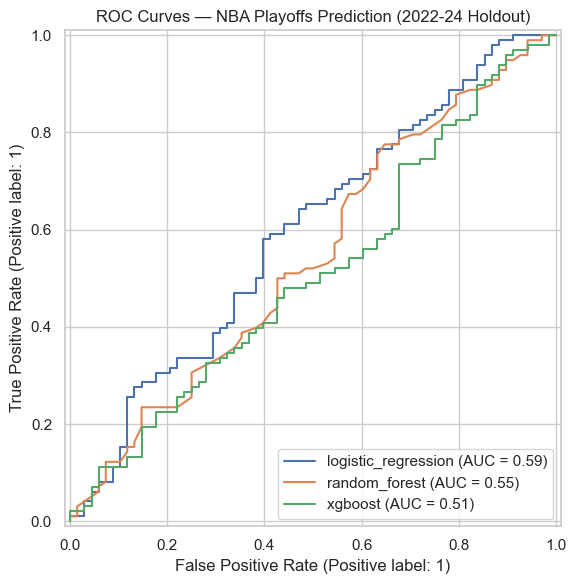

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curves — NBA Playoffs Prediction (2022-24 Holdout)")
plt.tight_layout()
plt.show()

## 7. Calibration Curves

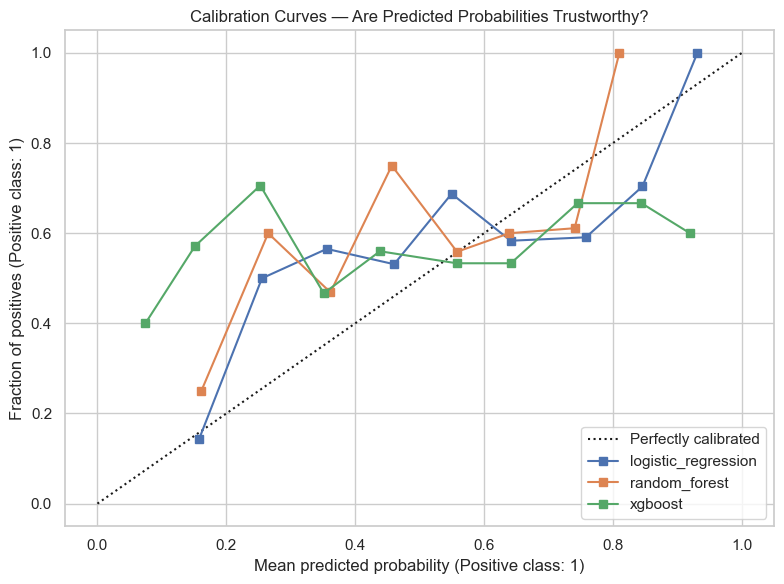

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models.items():
    CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=ax, name=name)
ax.set_title("Calibration Curves — Are Predicted Probabilities Trustworthy?")
plt.tight_layout()
plt.show()

## 8. Save Best Model

In [10]:
# Pick best by ROC-AUC on holdout
best_name = max(holdout_results, key=lambda k: holdout_results[k]["roc_auc"])
best_model = models[best_name]
path = save_model(best_model, best_name)
print(f"Best model: {best_name} — saved to {path}")

Best model: logistic_regression — saved to /Users/mearly/dev/playground/Sports/nba-playoffs/models/logistic_regression.joblib
